In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

OBSERVAÇÃO!!

Para testar com uma imagem diferente, adicione o caminho da imagem abaixo e atribua à variável imagem:

imagem4 = cv2.imread('dataset/nova_imagem.png')

imagem = imagem4

Desse modo, todas as células subsequentes processarão automaticamente a nova 
imagem, sem necessidade de qualquer outra alteração no código.


Outros casos de testes podem ser encontrados em imagens_transformada/tarefaX.

Os plt.imsave() estã comentados para não alterar os arquivos de testes.

In [ ]:
imagem = cv2.imread('dataset/watch.png')
imagem2 = cv2.imread('dataset/after_hours.png')
imagem3 = cv2.imread('dataset/blue_velvet.png')
imagem4 = cv2.imread('dataset/tenshi.png')

imagem = imagem4

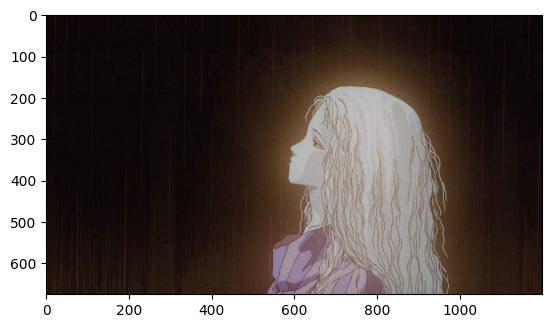

In [ ]:
plt.imshow(imagem)

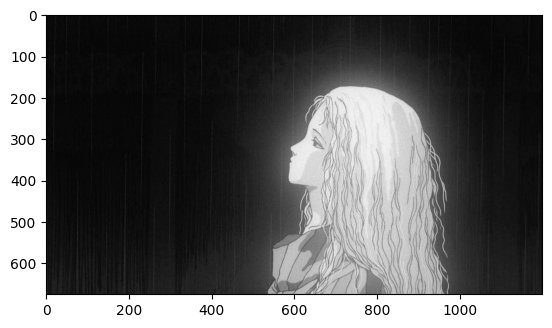

In [ ]:
imagem_mono = np.zeros_like(imagem).astype(np.float64)
imagem_mono =  0.2989*imagem[:,:,2] + 0.5870*imagem[:,:,1] + 0.1140*imagem[:,:,0]

plt.imshow(imagem_mono, cmap='gray')

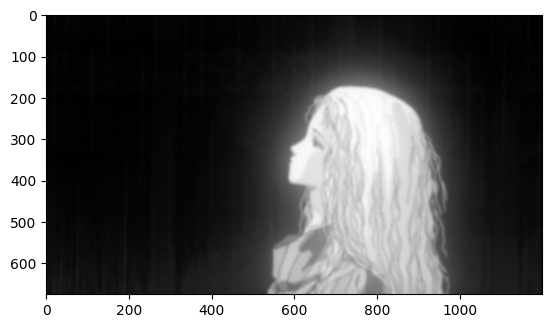

In [83]:
def mascara_gausiana(size, sigma=1.0):
    centro = size // 2
    x = np.arange(0, size) - centro         
    gauss_1d = np.exp(-x**2 / (2 * sigma**2))
    gauss_1d /= gauss_1d.sum()              
    kernel = np.outer(gauss_1d, gauss_1d)    
    return kernel

K = mascara_gausiana(21, sigma=3.0)

imagem_suavizada = cv2.filter2D(imagem_mono,-1, K, borderType=cv2.BORDER_REFLECT)

plt.imshow(imagem_suavizada, cmap="gray")

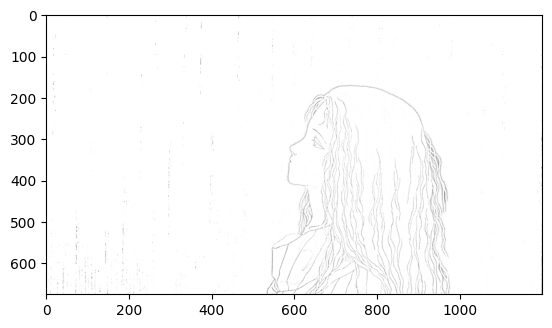

In [ ]:
epsilon = 6
desenho = imagem_mono / (imagem_suavizada - epsilon) * 255
desenho = np.clip(desenho, 0, 255).astype(np.uint8)

plt.imshow(desenho, cmap="gray")
#plt.imsave('imagens_transformadas/tarefa3/tenshi_draw.png', desenho, cmap="grey")